In [1]:
import torch, sys, h5py, os
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import seaborn as sns

In [2]:
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32', trust_remote_code=True)
nucleotides = list('acgt')

In [3]:
def process_array_by_groups(arr, true_token_ids, group_size=3):
    tokenProb = []
    for row, token_id in zip(arr, true_token_ids):
        curToken = tokenizer.convert_ids_to_tokens(int(token_id))
        curProb = row[nucleotides.index(curToken)]
        tokenProb.append(curProb)
    
    avg_tokenProb = [np.mean(tokenProb[i:i+group_size]) for i in range(0, len(tokenProb), group_size)]
    return avg_tokenProb


def create_binary_labels(label):
    return 1 if label == "Core Gene" else 0

In [4]:
y_true_dict = {}
y_scores_dict = {}
results_dict = {}
for suffix in ['ATG', 'A', 'T', 'G']:
    label = pd.read_csv('splice_junctions/B73_start_sites_filtered_labels.tsv', sep='\t')
    with h5py.File(f'splice_junctions/B73_start_sites_filtered_{suffix}.h5', 'r') as hf:
        predicted_logits = hf['predicted_logits'][:]
        true_token_ids = hf['true_token_ids'][:]
    logits = predicted_logits[:, [tokenizer.get_vocab()[nc] for nc in nucleotides]] # only retain atcg
    logits_tensor = torch.tensor(logits)
    probs = torch.nn.functional.softmax(logits_tensor, dim=1).numpy()
    
    if suffix != 'ATG':
        scores = probs[:,nucleotides.index(suffix.lower())]
    else:
        scores = process_array_by_groups(probs, true_token_ids, group_size=3)
    label['score'] = scores
    results_dict[suffix] = label
    subsets = label[label['Label'] != 'Near-Core Gene'].copy()
    subsets['binary_label'] = subsets['Label'].apply(create_binary_labels)
    y_true = subsets['binary_label'].values
    y_scores = subsets['score'].values
    y_true_dict[suffix] = y_true
    y_scores_dict[suffix] = y_scores

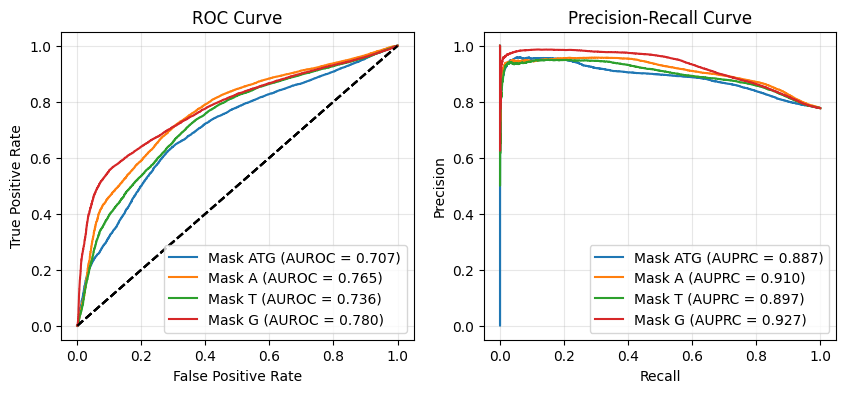

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for suffix in ['ATG', 'A', 'T', 'G']:
    y_true, y_scores = y_true_dict[suffix], y_scores_dict[suffix]
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_true, y_scores)
    ax1.plot(fpr, tpr, label=f'Mask {suffix} (AUROC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--') 

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

for suffix in ['ATG', 'A', 'T', 'G']:
    y_true, y_scores = y_true_dict[suffix], y_scores_dict[suffix]
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_true, y_scores)
    ax2.plot(recall, precision, label=f'Mask {suffix} (AUPRC = {pr_auc:.3f})')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

In [15]:
def plot_multiple_score_densities(data_dict, titles=None, figsize=(14, 10)):
    if len(data_dict) > 4:
        print("Warning: Only the first 4 datasets will be plotted in the 2x2 grid")
        data_list = data_list[:4]
    

    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    # Plot each dataset
    for i, key in enumerate(data_dict.keys()):
        if i >= 4:  # Only use the first 4 subplots
            break
            
        ax = axes[i]
        
        curdata = data_dict[key]
        
        core = curdata.loc[curdata['Label'] == 'Core Gene', 'score']
        near_core = curdata.loc[curdata['Label'] == 'Near-Core Gene', 'score']
        diepensable = curdata.loc[curdata['Label'] == 'Dispensable Gene', 'score']
        private = curdata.loc[curdata['Label'] == 'Private Gene', 'score']

        sns.kdeplot(core, ax=ax, fill=True, alpha=0.5, label='Core Gene')
        sns.kdeplot(near_core, ax=ax, fill=True, alpha=0.5, label='Near-Core Gene')
        sns.kdeplot(diepensable, ax=ax, fill=True, alpha=0.5, label='Dispensable Gene')
        sns.kdeplot(private, ax=ax, fill=True, alpha=0.5, label='Private Gene')
        
        
        # Add vertical lines for the median values
        ax.axvline(np.median(core), linestyle='--', color = 'C0', linewidth=2, label='Median (Core Gene)')
        ax.axvline(np.median(near_core), linestyle='--', color = 'C1', linewidth=2, label='Median (Near-Core Gene)')
        ax.axvline(np.median(diepensable), linestyle='--', color = 'C2',  linewidth=2, label='Median (Dispensable Gene)')
        ax.axvline(np.median(private), linestyle='--', color = 'C3', linewidth=2, label='Median (Private Gene)')
        
        # Add labels and title
        ax.set_xlabel('Prediction Score', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(titles[i], fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide any unused subplots
    for i in range(len(data_dict), 4):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()


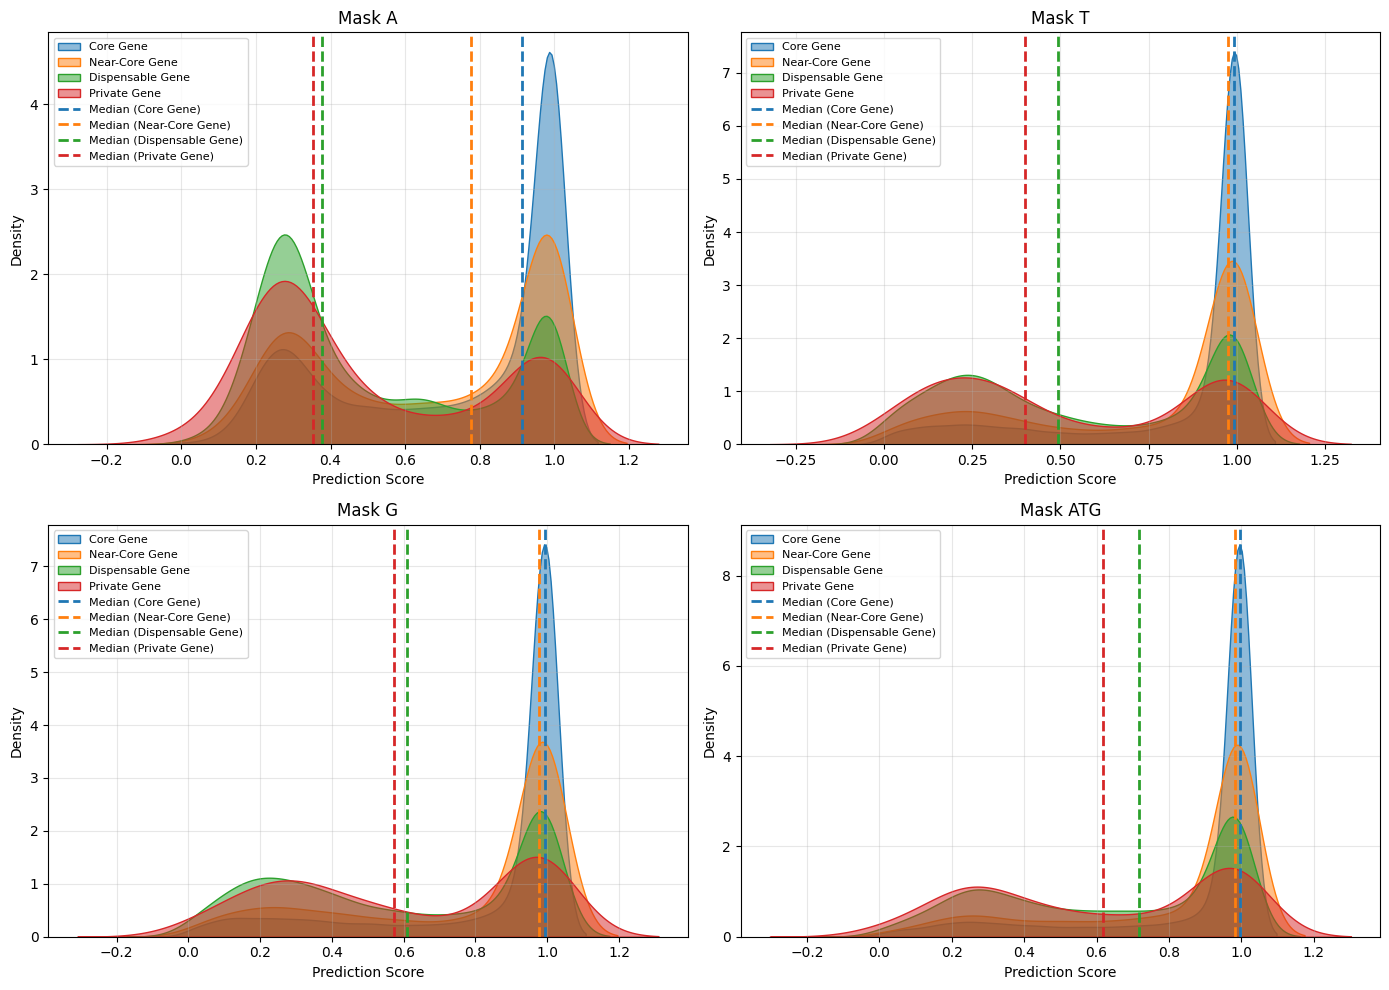

In [16]:
titles = ["Mask A", "Mask T", "Mask G", "Mask ATG"]
plot_multiple_score_densities(results_dict, titles)

In [17]:
def plot_multiple_score_boxplots(data_dict, titles=None, figsize=(14, 10)):
    if len(data_dict) > 4:
        print("Warning: Only the first 4 datasets will be plotted in the 2x2 grid")
        data_dict = {k: data_dict[k] for k in list(data_dict.keys())[:4]}
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    # Plot each dataset
    for i, key in enumerate(data_dict.keys()):
        if i >= 4:  # Only use the first 4 subplots
            break
            
        ax = axes[i]
        
        curdata = data_dict[key]
        
        # Create a list to store data for boxplot
        box_data = []
        labels = []
        
        # Collect data for each category
        for category in ['Core Gene', 'Near-Core Gene', 'Dispensable Gene', 'Private Gene']:
            values = curdata.loc[curdata['Label'] == category, 'score']
            if not values.empty:
                box_data.append(values)
                labels.append(category)
        
        # Create boxplot
        bp = ax.boxplot(box_data, patch_artist=True, labels=labels)
        
        # Customize boxplot colors
        colors = ['C0', 'C1', 'C2', 'C3']
        for patch, color in zip(bp['boxes'], colors[:len(box_data)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        
        # Add labels and title
        ax.set_xlabel('Gene Category', fontsize=10)
        ax.set_ylabel('Prediction Score', fontsize=10)
        ax.set_title(titles[i] if titles is not None else key, fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Rotate x-axis labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Hide any unused subplots
    for i in range(len(data_dict), 4):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

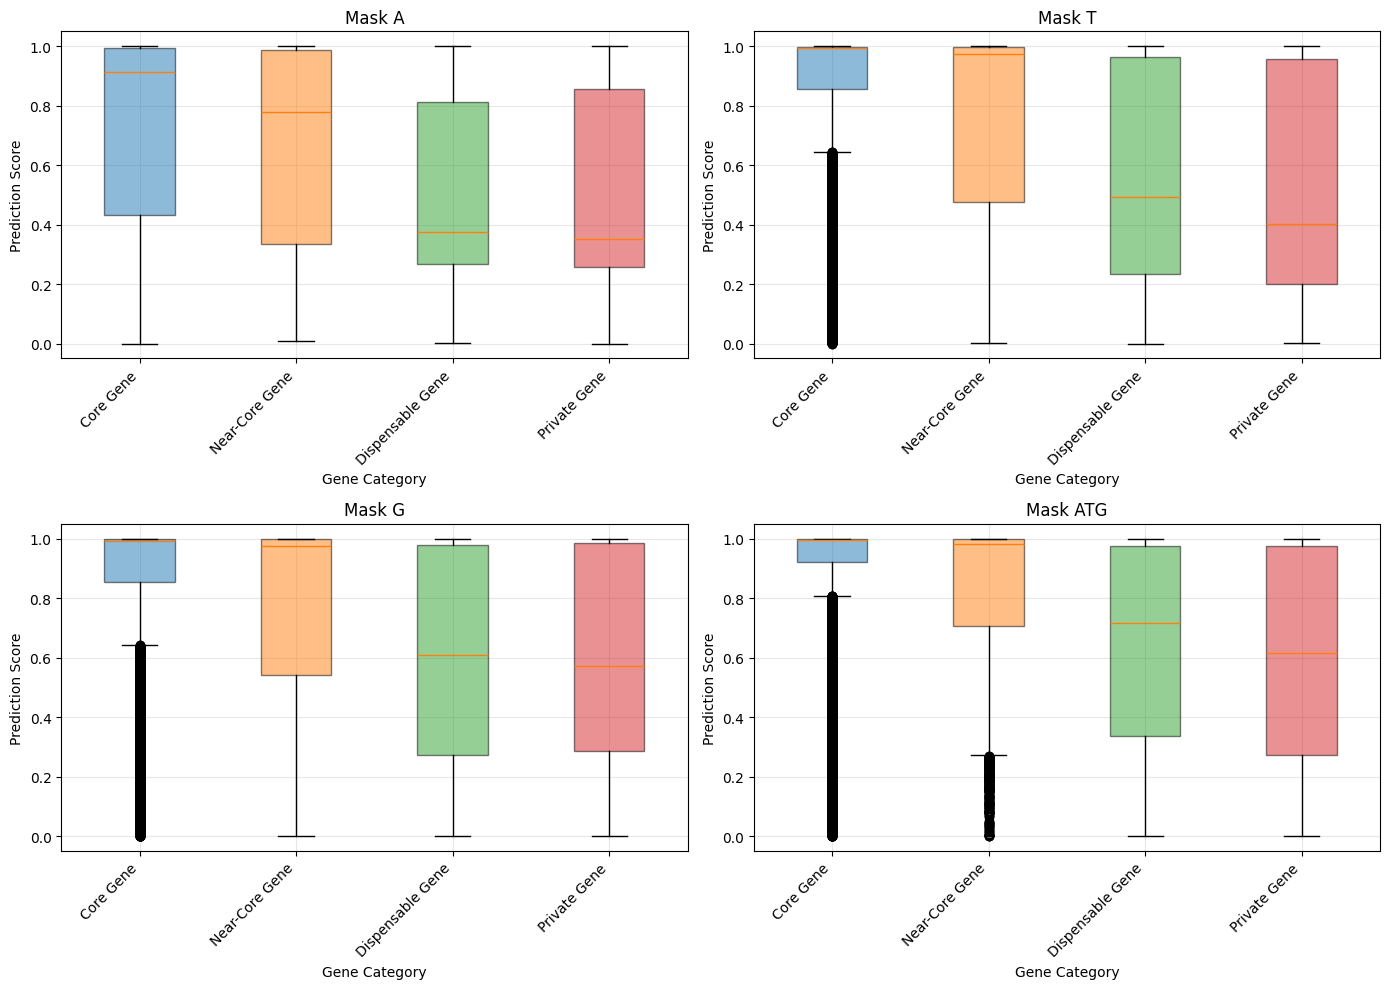

In [18]:
titles = ["Mask A", "Mask T", "Mask G", "Mask ATG"]
plot_multiple_score_boxplots(results_dict, titles)